In [53]:
import warnings
import xarray as xr
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import shapely
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as cx
import re
from exactextract import exact_extract
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyBboxPatch
from lonboard import viz
from pyproj import Geod
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import contextily as cx
import geopandas as gpd
import pandas as pd
from matplotlib.lines import Line2D
import rioxarray as rxr
import pyproj
import rasterio
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning) # exactextract gives a warning that is invalid

In [54]:
BASE_DIR = Path(r"C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia")
sys.path.append(str(BASE_DIR))
from utils.utils import read_road_network, assign_flood_depth_to_roads
from utils.arcgis import save_lyrx_layer

In [55]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / 'intermediate_results'
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpgk = arcgis_results / "Geopackages" 

In [56]:
# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_bounds = world.loc[world.SOV_A3 == 'SRB'].bounds
country_plot = world.loc[world.SOV_A3 == 'SRB']

In [57]:
# Load baseline road network
#baseline_roads = read_road_network(intermediate_results_path / "PERS_directed_final.parquet")
baseline_roads = gpd.read_file(data_path / "Deonice_Februar_2025.shp")

In [58]:
# Load country outlines
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)

# Extract Serbia and Kosovo polygons
# Serbia's SOV_A3 code is 'SRB', Kosovo's is 'KOS'
serbia = world.loc[world.SOV_A3 == 'SRB']
kosovo = world.loc[world.SOV_A3 == 'KOS']

# Reproject to match road network CRS
serbia = serbia.to_crs(baseline_roads.crs)
kosovo = kosovo.to_crs(baseline_roads.crs)

# Clip road network to each country
serbia_roads = gpd.clip(baseline_roads, serbia)
kosovo_roads = gpd.clip(baseline_roads, kosovo)

In [59]:
serbia_roads_mercator = serbia_roads.to_crs(3857)
kosovo_roads_mercator = kosovo_roads.to_crs(3857)
baseline_roads_mercator = baseline_roads.to_crs(3857)

In [60]:
# read flood data
fluvial_flooding_path = data_path / "Europe_RP100_filled_depth.tif"

In [61]:
hazard_map = xr.open_dataset(fluvial_flooding_path, engine="rasterio")
hazard_country = hazard_map.rio.clip_box(minx=country_bounds.minx.values[0],
                 miny=country_bounds.miny.values[0],
                 maxx=country_bounds.maxx.values[0],
                 maxy=country_bounds.maxy.values[0]
                ).load()

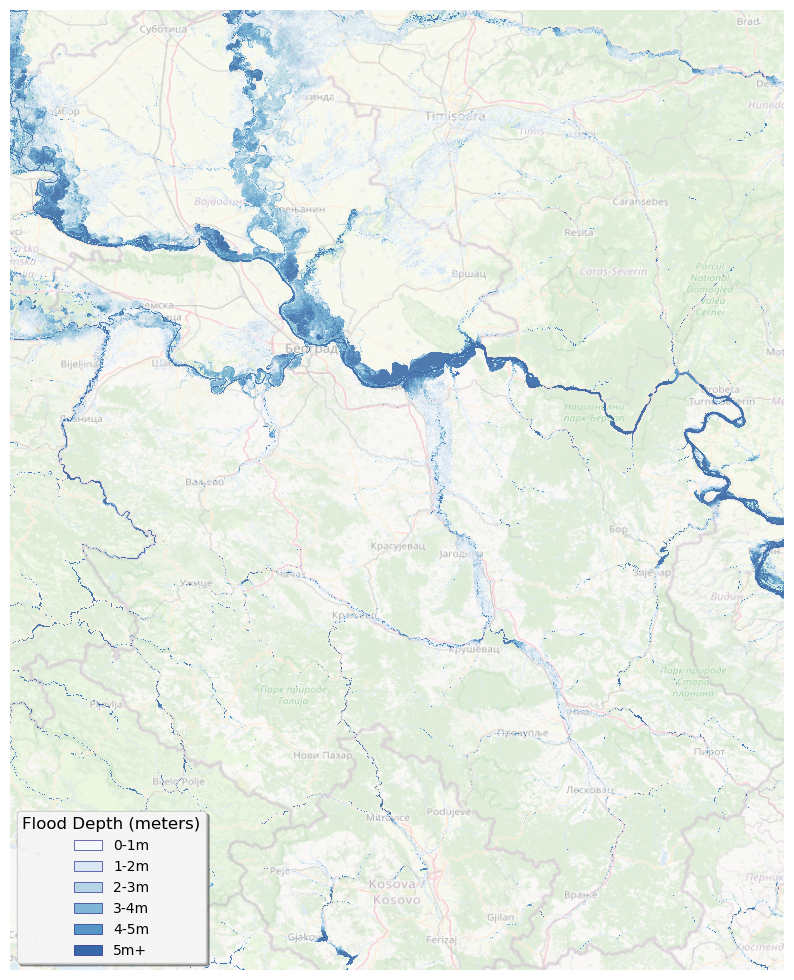

In [62]:
# Create figure with high DPI for crisp visuals
fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

# Create blue flood risk colormap - light to dark blue
# Light blue (low/no risk) to dark blue (high risk)
flood_colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']
flood_cmap = LinearSegmentedColormap.from_list('flood_blue', flood_colors, N=256)

# Plot the flood hazard xarray data


# Check if data needs reprojection (assuming WGS84 lat/lon input)
if hazard_country.rio.crs is None:
    hazard_country = hazard_country.rio.write_crs("EPSG:4326")

# Reproject to Web Mercator for basemap overlay
hazard_mercator = hazard_country.rio.reproject("EPSG:3857")

# Plot the raster data
flood_plot = hazard_mercator.band_data.plot(
    ax=ax,
    cmap=flood_cmap,
    alpha=0.7,  # Semi-transparent so basemap shows through
    vmin=0,
    vmax=6,     # Updated for 5+ meter depths
    add_colorbar=False,  # We'll create a custom legend and colorbar
    add_labels=False, 
)

# Add basemap with optimal styling for PNG
# Add basemap with optimal styling for PNG
cx.add_basemap(
    ax=ax, 
    source=cx.providers.OpenStreetMap.Mapnik,
    alpha=0.4,
    attribution=False
)

# Enhance the plot styling
ax.axis('off')  # Remove axis for cleaner look

# Create flood risk categories for legend - in 1-meter increments
flood_bins = [0, 1, 2, 3, 4, 5, np.inf]
flood_labels = ['0-1m', '1-2m', '2-3m', '3-4m', '4-5m', '5m+']

# Get colors for legend from the blue colormap
legend_colors = [flood_cmap(i/5) for i in range(6)]  # 6 categories now

# Create custom legend in upper right corner
legend_elements = [Patch(facecolor=legend_colors[i], 
                        label=flood_labels[i], 
                        edgecolor='navy', 
                        linewidth=0.5, 
                        alpha=0.8) 
                  for i in range(len(flood_labels))]

legend = ax.legend(handles=legend_elements, 
                  title='Flood Depth (meters)', 
                  loc='lower left',
                  fontsize=10,
                  title_fontsize=12,
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  framealpha=0.9,
                  facecolor='white',
                  edgecolor='#cccccc')

# Add subtitle with flood data info
flood_data = hazard_country.band_data.values.flatten()
flood_data_clean = flood_data[~np.isnan(flood_data)]

# Enhance overall plot appearance
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.08, left=0.02, right=0.88)  # Make room for colorbar
plt.savefig(figure_path / 'flood_depth_map.png', dpi=600, bbox_inches='tight')
plt.show()

Roads with flood depth assigned : 2,213
Roads with no flooding          : 3,277
Flood depth range               : 0.10 – 54.62 m


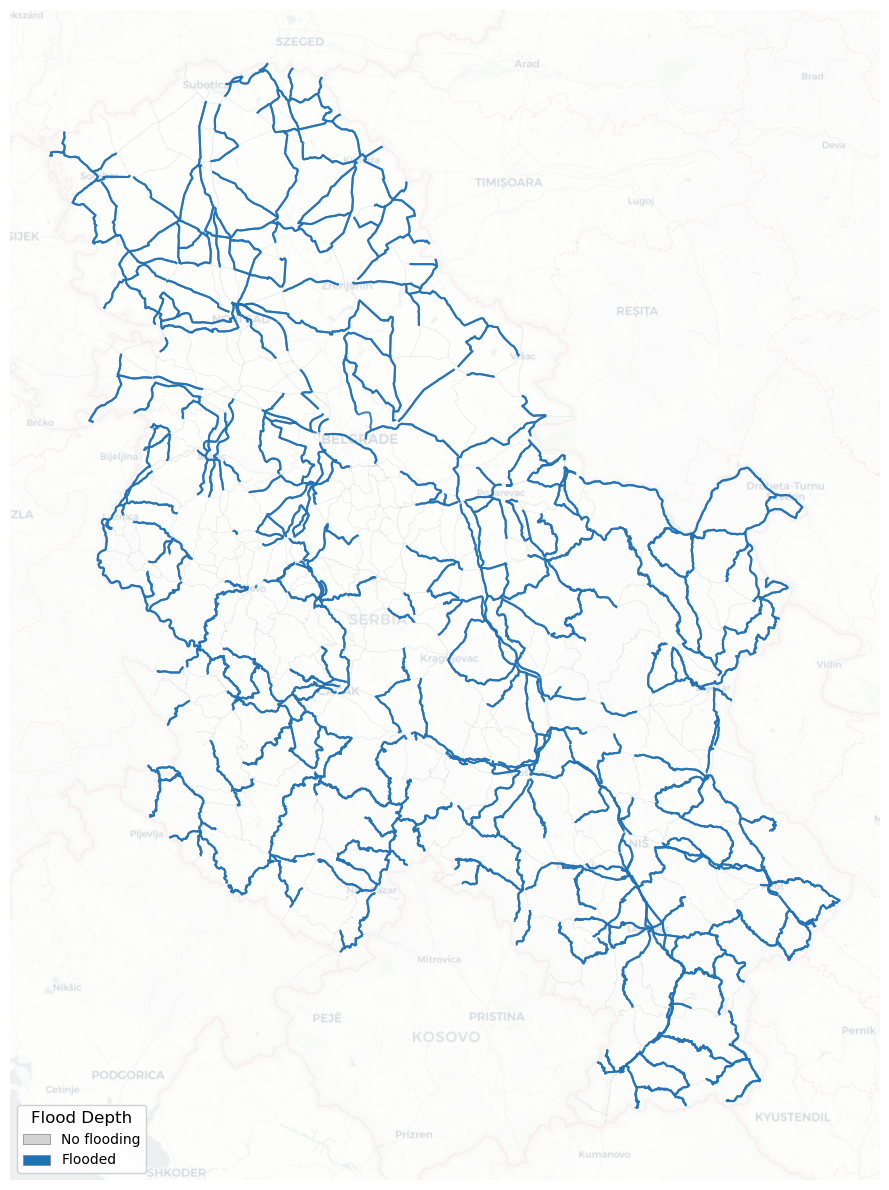

Saved GeoPackage → C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\results\ArcGIS layers\Geopackages\flood_depth_roads.gpkg


In [63]:
# Assign flood depth to roads
roads = read_road_network(intermediate_results_path / "PERS_directed_final.parquet")
roads = assign_flood_depth_to_roads(
    roads=roads,
    raster_data=hazard_country.band_data.values.squeeze(),  # (1, rows, cols) → (rows, cols)
    raster_bounds=hazard_country.rio.bounds(),
    raster_crs=hazard_country.rio.crs,
)
roads["flood_class"] = roads["flood_class"].apply(
    lambda x: "No flooding" if x == "No flooding" else "Flooded"
)

original_crs = roads.crs

# Plot
roads_plot = roads.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor="white")

# Not flooded
roads_plot[roads_plot["flood_class"] == "No flooding"].plot(
    ax=ax, color="#d3d3d3", linewidth=0.3, alpha=0.4, zorder=1
)

# Flooded
roads_plot[roads_plot["flood_class"] != "No flooding"].plot(
    ax=ax, color="#2171b5", linewidth=1.5, alpha=0.85, zorder=2
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
ax.axis("off")

legend_handles = [
    Patch(facecolor="#d3d3d3", label="No flooding", edgecolor="grey", linewidth=0.5),
    Patch(facecolor="#2171b5", label="Flooded",     edgecolor="grey", linewidth=0.5),
]
ax.legend(handles=legend_handles, title="Flood Depth", loc="lower left",
          fontsize=10, title_fontsize=12, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig(figure_path / "flood_depth_roads.png", dpi=600, bbox_inches="tight")
plt.show()

save_lyrx_layer(
    gdf=roads.to_crs(original_crs),
    gpkg_path=arcgis_gpgk / "flood_depth_roads.gpkg",
    lyrx_path=arcgis_results / "flood_depth_roads.lyrx",
    layer_name="flood_depth_roads",
    labels=["No flooding", "Flooded"],
    colors=["#d3d3d3", "#2171b5"],
    width_mapping={"No flooding": 0.3, "Flooded": 1.5},
    field="flood_class",
    title="Flood Depth on Roads",
)

In [64]:
snow_drift = gpd.read_file(data_path / "snezni_nanosi_studije.shp")

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


<module 'matplotlib.pyplot' from 'c:\\Users\\yma794\\AppData\\Local\\miniforge3\\envs\\criticality_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

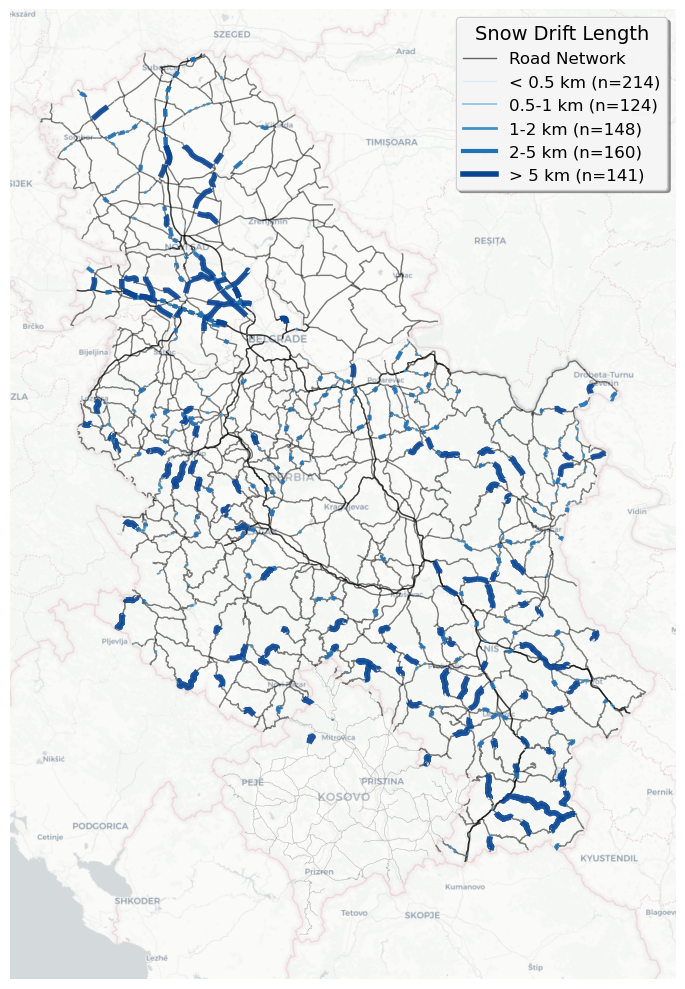

In [ ]:
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Convert to Web Mercator for basemap
serbia_mercator = country_plot.to_crs(3857)
snow_drift_mercator = snow_drift.to_crs(3857)

# Define length bins and labels (in km)
bins = [0, 0.5, 1, 2, 5, float('inf')]
labels = ['< 0.5 km', '0.5-1 km', '1-2 km', '2-5 km', '> 5 km']
snow_drift_mercator['length_class'] = pd.cut(
    snow_drift_mercator['dužina_sn'], 
    bins=bins, labels=labels, include_lowest=True
)

# Define colors and linewidths - longer = thicker/darker
colors = {
    '< 0.5 km': '#deebf7',
    '0.5-1 km': '#9ecae1', 
    '1-2 km': '#4292c6',
    '2-5 km': '#2171b5',
    '> 5 km': '#084594'
}

linewidths = {
    '< 0.5 km': 1.0,
    '0.5-1 km': 1.5, 
    '1-2 km': 2.0,
    '2-5 km': 3.0,
    '> 5 km': 4.0
}

# Plot country outline first
#serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=1.5, zorder=2)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

# Plot snow drifts by length class on top
for length_class in labels:
    subset = snow_drift_mercator[snow_drift_mercator['length_class'] == length_class]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colors[length_class], 
                    linewidth=linewidths[length_class], 
                    alpha=0.9, zorder=3)

# Add basemap
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)

ax.set_aspect('equal')
ax.axis('off')

# Create legend
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6)
] + [
    Line2D([0], [0], color=colors[label], linewidth=linewidths[label],
           label=f'{label} (n={len(snow_drift_mercator[snow_drift_mercator["length_class"] == label])})')
    for label in labels
]
ax.legend(handles=legend_elements, title='Snow Drift Length', loc='upper right', 
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'snow_drift_map.png', dpi=600, bbox_inches='tight')
plt

In [66]:
landslides = gpd.read_file(data_path / "Nestabilne_pojave.shp")

In [67]:
print("Total number of unstable occurances:")
print(len(landslides))

Total number of unstable occurances:
460


In [68]:
# Filter to true landslides only (tip == 'Klizište')
# Excluding: rockfalls (Odron/Osuline), slope detachments (Otcepljenje kosine),
# debris flows (Tecište), and degraded road surfaces (Degradiran kolovozni zastor)
landslides = landslides[landslides['tip'] == 'Klizište']

In [69]:
print("number of landslide occurances:")
print(len(landslides))

number of landslide occurances:
289


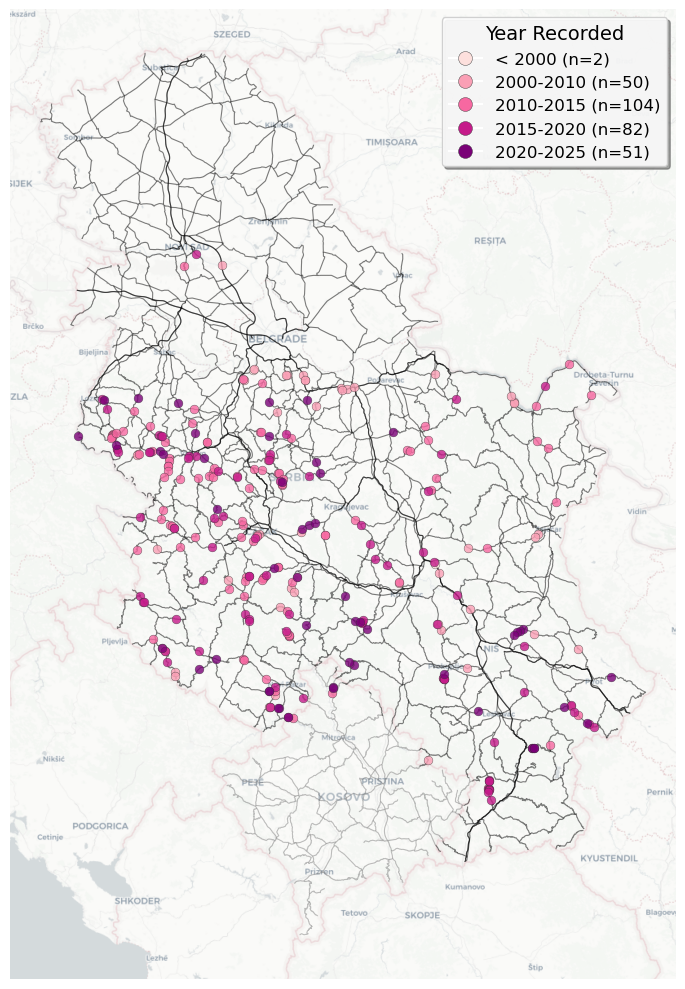

In [70]:
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Convert to Web Mercator for basemap
serbia_mercator = country_plot.to_crs(3857)
landslides_mercator = landslides.to_crs(3857)

# Extract year from datum_evid
landslides_mercator['year'] = pd.to_datetime(landslides_mercator['datum_evid']).dt.year

# Define year bins and labels
bins = [0, 2000, 2010, 2015, 2020, 2030]
labels = ['< 2000', '2000-2010', '2010-2015', '2015-2020', '2020-2025']
landslides_mercator['year_class'] = pd.cut(
    landslides_mercator['year'], 
    bins=bins, labels=labels, include_lowest=True
)

# Define colors - sequential from light to dark (older to newer)
colors = {
    '< 2000': '#fde0dd',
    '2000-2010': '#fa9fb5', 
    '2010-2015': '#f768a1',
    '2015-2020': '#c51b8a',
    '2020-2025': '#7a0177'
}

# Plot country outline first (as background)
#serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',linewidth=1.5, zorder=2)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

# Plot landslides by year class
for year_class in labels:
    subset = landslides_mercator[landslides_mercator['year_class'] == year_class]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colors[year_class], markersize=40, 
                    alpha=0.8, edgecolor='#333333', 
                    linewidth=0.3, zorder=3)

# Add basemap
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)

ax.set_aspect('equal')
ax.axis('off')

# Create legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=colors[label], markersize=10,
           markeredgecolor='#333333', markeredgewidth=0.3,
           label=f'{label} (n={len(landslides_mercator[landslides_mercator["year_class"] == label])})')
    for label in labels
]
ax.legend(handles=legend_elements, title='Year Recorded', loc='upper right', 
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'landslides_map_by_year.png', dpi=600, bbox_inches='tight')
plt.show()

In [71]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.warp import transform_bounds
import contextily as cx


Binary wildfire risk map generated (classed areas = risk)


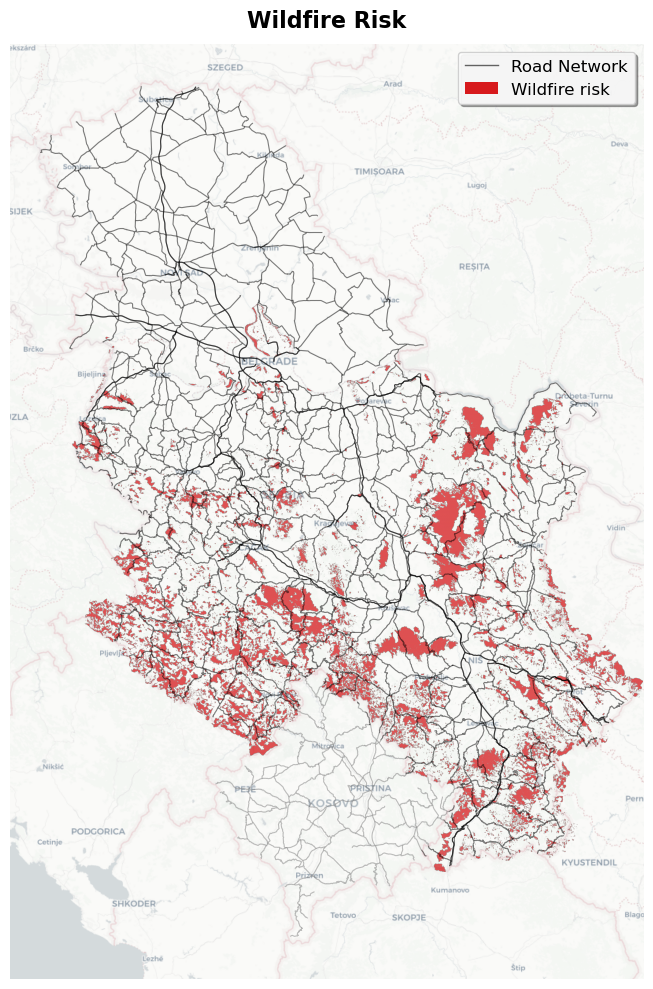

In [72]:
path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

# --- Load data ---
with rasterio.open(path) as src:
    scale_factor = 10
    out_shape = (1, int(src.height / scale_factor), int(src.width / scale_factor))
    data = src.read(
        1,
        out_shape=out_shape,
        resampling=rasterio.enums.Resampling.nearest
    ).astype(float)

    data[data == src.nodata] = np.nan

    fire_bounds = src.bounds
    fire_crs = src.crs
    bounds_mercator = transform_bounds(
        fire_crs, "EPSG:3857",
        fire_bounds.left, fire_bounds.bottom,
        fire_bounds.right, fire_bounds.top
    )

# ------------------------------------------------------------------
# Binary wildfire risk classification
# 1 = Wildfire risk (any valid class 1-6)
# 0 = No wildfire risk (no data / no class)
# ------------------------------------------------------------------
binary_data = np.where(np.isfinite(data), 1, 0)

# --- Binary color scheme ---
# Blue = no wildfire risk, Red = wildfire risk
risk_colors = {
    1: mcolors.to_rgba('#d7191c', alpha=0.75)   # Wildfire risk
}

# --- Build RGBA array ---
color_array = np.zeros((*binary_data.shape, 4))
for val, rgba in risk_colors.items():
    color_array[binary_data == val] = rgba

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)

ax.imshow(
    color_array,
    extent=[
        bounds_mercator[0], bounds_mercator[2],
        bounds_mercator[1], bounds_mercator[3]
    ],
    zorder=2,
    origin='upper'
)

#serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=1.5, zorder=4)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.Positron,
    attribution=False
)

ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    "Wildfire Risk",
    fontsize=16, fontweight='bold', pad=12
)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1,
           label='Road Network', alpha=0.6),
    Patch(facecolor='#d7191c', edgecolor='none',
          label='Wildfire risk')
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=12,
    title_fontsize=14,
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig(
    figure_path / "binary_wildfire_risk_map.png",
    dpi=600,
    bbox_inches='tight'
)

print("Binary wildfire risk map generated (classed areas = risk)")
plt.show()

In [73]:
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.features import geometry_mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
import contextily as cx

Assigning binary wildfire risk to roads...

Binary wildfire risk distribution across road network:
wildfire_risk
0    1575
1     444
Name: count, dtype: int64
Saved GeoPackage → C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\results\ArcGIS layers\Geopackages\wildfire_risk_roads.gpkg


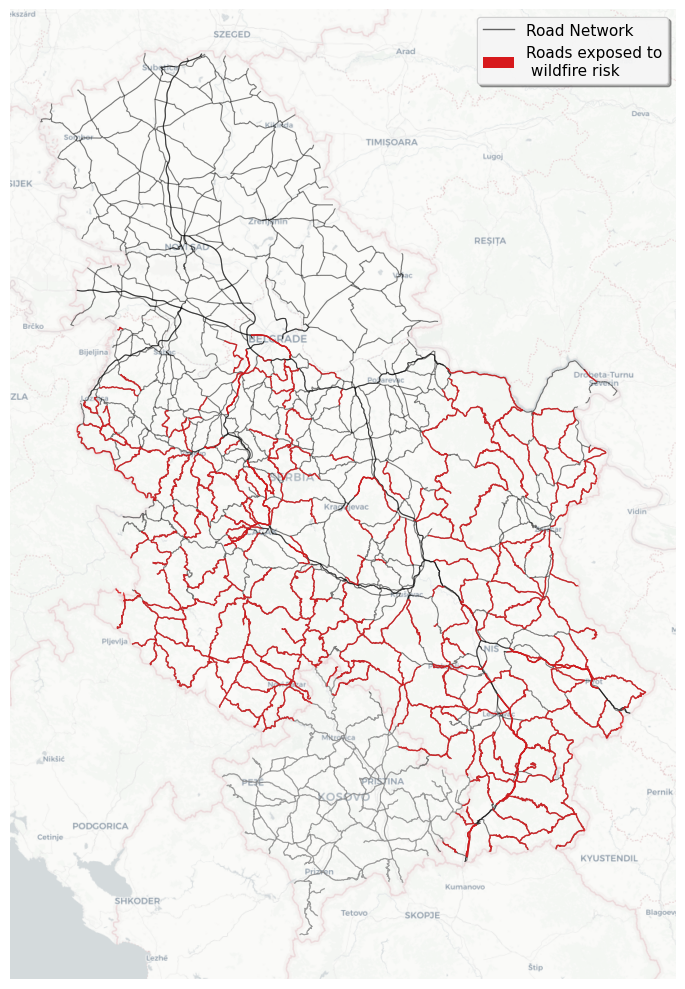

In [74]:
def assign_binary_wildfire_risk_to_roads(raster_path, roads_gdf, buffer_meters=10):
    """
    Assign binary wildfire risk to roads:
    1 = wildfire risk (any raster value > 0 within buffer)
    0 = no wildfire risk (only 0 or nodata)
    """
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        nodata = src.nodata
        transform = src.transform
        raster_window = rasterio.windows.Window(0, 0, src.width, src.height)

        roads_reproj = roads_gdf.to_crs(raster_crs)
        wildfire_risk = []

        for geom in roads_reproj.geometry:
            try:
                buffered = geom.buffer(buffer_meters)

                bounds = buffered.bounds
                window = rasterio.windows.from_bounds(
                    bounds[0], bounds[1], bounds[2], bounds[3], transform
                ).round_lengths().round_offsets()

                if not rasterio.windows.intersect(window, raster_window):
                    wildfire_risk.append(0)
                    continue

                window = rasterio.windows.intersection(window, raster_window)
                if window.width < 1 or window.height < 1:
                    wildfire_risk.append(0)
                    continue

                data = src.read(1, window=window)
                win_transform = src.window_transform(window)

                mask = geometry_mask(
                    [mapping(buffered)],
                    out_shape=data.shape,
                    transform=win_transform,
                    invert=True
                )

                pixels = data[mask & (data != nodata)]

                # --- Binary rule: any value > 0 = wildfire risk ---
                wildfire_risk.append(1 if np.any(pixels > 0) else 0)

            except Exception:
                wildfire_risk.append(0)

        result = roads_reproj.copy()
        result["wildfire_risk"] = wildfire_risk
        result = result.to_crs(roads_gdf.crs)
        return result


# ── 2. Run the function ───────────────────────────────────────────────────────

fire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

print("Assigning binary wildfire risk to roads...")
roads_with_risk = assign_binary_wildfire_risk_to_roads(
    fire_path,
    baseline_roads,
    buffer_meters=10
)

roads_with_risk.to_parquet(
    intermediate_results_path / "roads_binary_wildfire_risk.parquet"
)

# Quick summary
print("\nBinary wildfire risk distribution across road network:")
print(roads_with_risk["wildfire_risk"].value_counts().sort_index())


# ── 3. Plot ───────────────────────────────────────────────────────────────────

risk_labels = {1: "Wildfire risk"}
risk_colors = {1: "#d7191c"}  # blue / red

fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor="white")

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads_with_risk.to_crs(3857)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)


subset = roads_mercator[roads_mercator["wildfire_risk"] == val]
if not subset.empty:
    subset.plot(
        ax=ax,
        color=risk_colors[val],
        linewidth=1.0,
        alpha=0.85,
        zorder=3
    )

#serbia_mercator.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)

kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.Positron,
    attribution=False
)

ax.set_aspect("equal")
ax.axis("off")

legend_elements =[
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6)
] + [
    Patch(facecolor=risk_colors[1], label="Roads exposed to\n wildfire risk")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=11,
    title_fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc"
)

plt.tight_layout()
plt.savefig(
    figure_path / "roads_binary_wildfire_risk.png",
    dpi=600,
    bbox_inches="tight"
)

# Restore original CRS and add wildfire_class column for ArcGIS styling
roads_with_risk["wildfire_class"] = roads_with_risk["wildfire_risk"].map({
    0: "No risk",
    1: "Wildfire risk",
})

save_lyrx_layer(
    gdf=roads_with_risk,
    gpkg_path=arcgis_gpgk / "wildfire_risk_roads.gpkg",
    lyrx_path=arcgis_results / "wildfire_risk_roads.lyrx",
    layer_name="wildfire_risk_roads",
    labels=["No risk", "Wildfire risk"],
    colors=["#000000", "#d7191c"],
    width_mapping={"No risk": 0.4, "Wildfire risk": 1.0},
    field="wildfire_class",
    title="Wildfire Risk on Roads",
)

plt.show()


In [75]:
counts = roads_with_risk["wildfire_risk"].value_counts(normalize=True) * 100

print("Percentage of road segments:")
print(f"No wildfire risk: {counts.get(0, 0):.2f}%")
print(f"Wildfire risk:    {counts.get(1, 0):.2f}%")

Percentage of road segments:
No wildfire risk: 78.01%
Wildfire risk:    21.99%


In [76]:
roads_metric = roads_with_risk.to_crs(3857)
roads_metric["length_m"] = roads_metric.geometry.length

length_summary = (
    roads_metric
    .groupby("wildfire_risk")["length_m"]
    .sum()
)

total_length = length_summary.sum()

pct_no_risk = 100 * length_summary.get(0, 0) / total_length
pct_risk = 100 * length_summary.get(1, 0) / total_length

print("Percentage of total road length:")
print(f"No wildfire risk: {pct_no_risk:.2f}%")
print(f"Wildfire risk:    {pct_risk:.2f}%")

Percentage of total road length:
No wildfire risk: 62.03%
Wildfire risk:    37.97%


In [77]:
import numpy as np
import rasterio


def calculate_wildfire_overlap_length_sampling(
    raster_path,
    roads_gdf,
    sampling_distance=30
):
    """
    Calculates actual road length overlapping wildfire risk (value > 0),
    excluding nodata and samples outside raster extent.
    """
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        nodata = src.nodata

        # --- Lengths in meters ---
        roads_metric = roads_gdf.to_crs(3857).copy()
        total_length = roads_metric.geometry.length.sum()
        exposed_length = 0.0

        # --- Sampling geometries in raster CRS ---
        roads_sampling = roads_metric.to_crs(raster_crs)

        for geom_metric, geom_raster in zip(
            roads_metric.geometry,
            roads_sampling.geometry
        ):
            try:
                if geom_metric.length == 0:
                    continue

                n_points = max(int(geom_metric.length // sampling_distance), 1)
                distances = np.linspace(0, geom_metric.length, n_points)

                points = [geom_raster.interpolate(d) for d in distances]
                coords = [(p.x, p.y) for p in points]

                # Sample raster
                samples = np.array(list(src.sample(coords))).flatten()

                # --- ✅ CRITICAL FIX: mask nodata explicitly ---
                valid = samples != nodata
                if valid.sum() == 0:
                    continue

                exposed_fraction = np.mean(samples[valid] > 0)

                exposed_length += exposed_fraction * geom_metric.length

            except Exception:
                continue

    pct_exposed = 100 * exposed_length / total_length if total_length > 0 else 0

    return total_length, exposed_length, pct_exposed


# ── Run calculation ───────────────────────────────────────────────────────────

fire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

total_len, overlap_len, pct_overlap = calculate_wildfire_overlap_length_sampling(
    fire_path,
    baseline_roads,
    sampling_distance=30
)

print("\nRoad-Wildfire Overlap Statistics (Sampling-based)")
print("------------------------------------------------")
print(f"Total road length:                {total_len / 1000:.2f} km")
print(f"Length overlapping wildfire risk: {overlap_len / 1000:.2f} km")
print(f"Percentage of road length exposed:{pct_overlap:.2f}%")


Road-Wildfire Overlap Statistics (Sampling-based)
------------------------------------------------
Total road length:                25858.77 km
Length overlapping wildfire risk: 8548.65 km
Percentage of road length exposed:33.06%


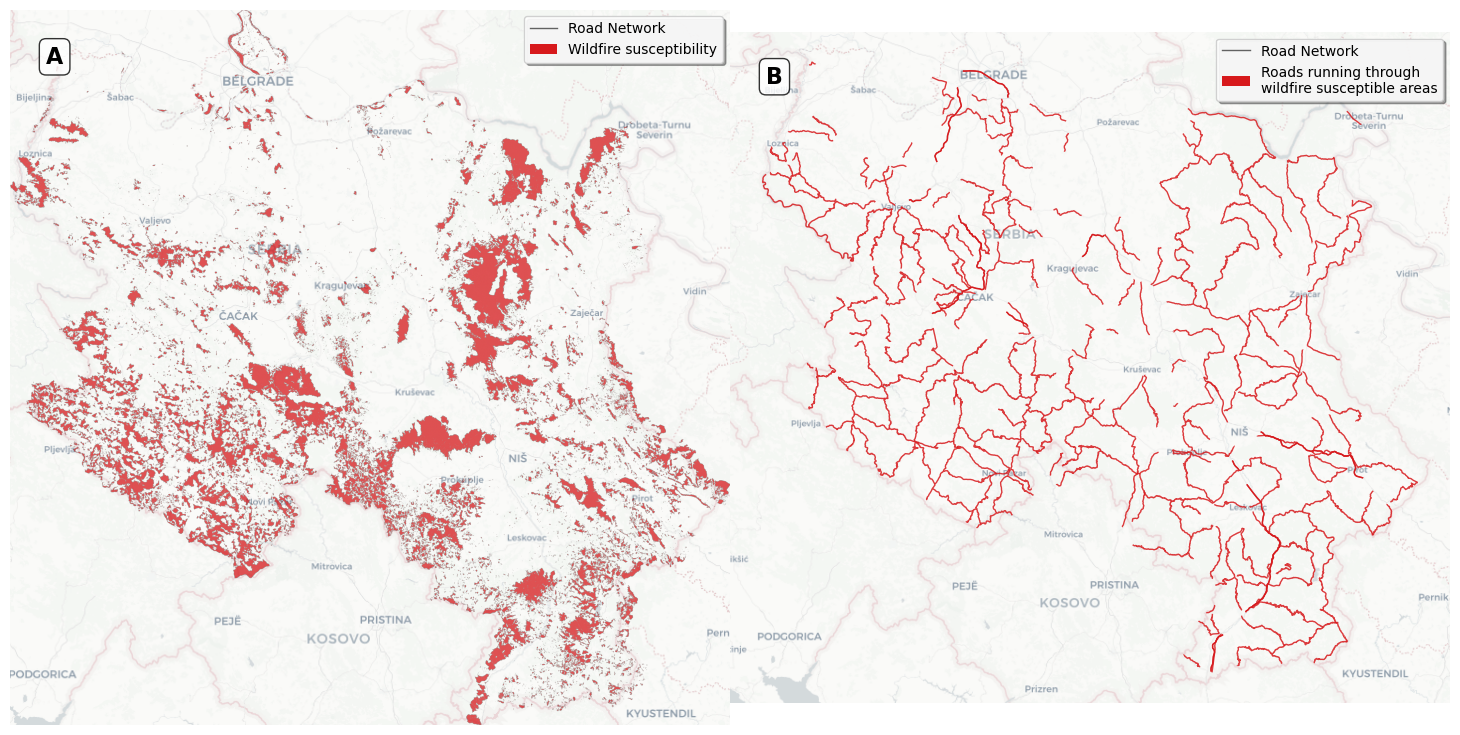

In [78]:
# ── Combined A/B wildfire risk figure ────────────────────────────────────────

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(15, 10),
    facecolor="white"
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.95,
    bottom=0.05,
    wspace=0.0
)

labels = ["A", "B"]

# ── Shared base layers ────────────────────────────────────────────────────────
serbia_mercator  = country_plot.to_crs(3857)
baseline_mercator = baseline_roads.to_crs(3857)
roads_mercator   = roads_with_risk.to_crs(3857)


# ══════════════════════════════════════════════════════════════════════════════
# Panel A - Raster wildfire risk map
# ══════════════════════════════════════════════════════════════════════════════
ax_a = axes[0]

# --- Load & downsample raster ---
fire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

with rasterio.open(fire_path) as src:
    scale_factor = 10
    out_shape = (1, int(src.height / scale_factor), int(src.width / scale_factor))
    data = src.read(
        1,
        out_shape=out_shape,
        resampling=rasterio.enums.Resampling.nearest
    ).astype(float)
    data[data == src.nodata] = np.nan

    fire_bounds = src.bounds
    fire_crs    = src.crs
    bounds_mercator = transform_bounds(
        fire_crs, "EPSG:3857",
        fire_bounds.left, fire_bounds.bottom,
        fire_bounds.right, fire_bounds.top
    )

# Binary classification: any finite value → risk
binary_data = np.where(np.isfinite(data), 1, 0)

color_array = np.zeros((*binary_data.shape, 4))
color_array[binary_data == 1] = mcolors.to_rgba("#d7191c", alpha=0.75)

ax_a.imshow(
    color_array,
    extent=[bounds_mercator[0], bounds_mercator[2],
            bounds_mercator[1], bounds_mercator[3]],
    zorder=2,
    origin="upper"
)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)
#serbia_mercator.plot(ax=ax_a, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)

cx.add_basemap(ax=ax_a, source=cx.providers.CartoDB.Positron, attribution=False)

ax_a.set_aspect("equal")
ax_a.axis("off")

legend_a = [
    Line2D([0], [0], color="black", linewidth=1, label="Road Network", alpha=0.6),
    Patch(facecolor="#d7191c", edgecolor="none", label="Wildfire susceptibility"),
]
ax_a.legend(
    handles=legend_a, loc="upper right", fontsize=10,
    frameon=True, fancybox=True, shadow=True,
    framealpha=0.9, facecolor="white", edgecolor="#cccccc"
)


# ══════════════════════════════════════════════════════════════════════════════
# Panel B - Roads exposed to wildfire risk
# ══════════════════════════════════════════════════════════════════════════════
ax_b = axes[1]

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

exposed = roads_mercator[roads_mercator["wildfire_risk"] == 1]
if not exposed.empty:
    exposed.plot(ax=ax_b, color="#d7191c", linewidth=1.0, alpha=0.85, zorder=3)

#serbia_mercator.plot(ax=ax_b, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)

cx.add_basemap(ax=ax_b, source=cx.providers.CartoDB.Positron, attribution=False)

ax_b.set_aspect("equal")
ax_b.axis("off")

legend_b = [
    Line2D([0], [0], color="black", linewidth=1, label="Road Network", alpha=0.6),
    Patch(facecolor="#d7191c", edgecolor="none", label="Roads running through \nwildfire susceptible areas"),
]
ax_b.legend(
    handles=legend_b, loc="upper right", fontsize=10,
    frameon=True, fancybox=True, shadow=True,
    framealpha=0.9, facecolor="white", edgecolor="#cccccc"
)


# ── A/B labels (top-left of each panel) ──────────────────────────────────────
for ax, label in zip(axes, labels):
    ax.text(
        0.05, 0.95, label,
        transform=ax.transAxes,
        fontsize=16, fontweight="bold",
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )


plt.savefig(figure_path / "wildfire_risk_AB.png", dpi=600, bbox_inches="tight")
plt.show()

In [79]:
#Load landslide susceptibility map
landslide_path = data_path / "landslide_susceptibility.tif"

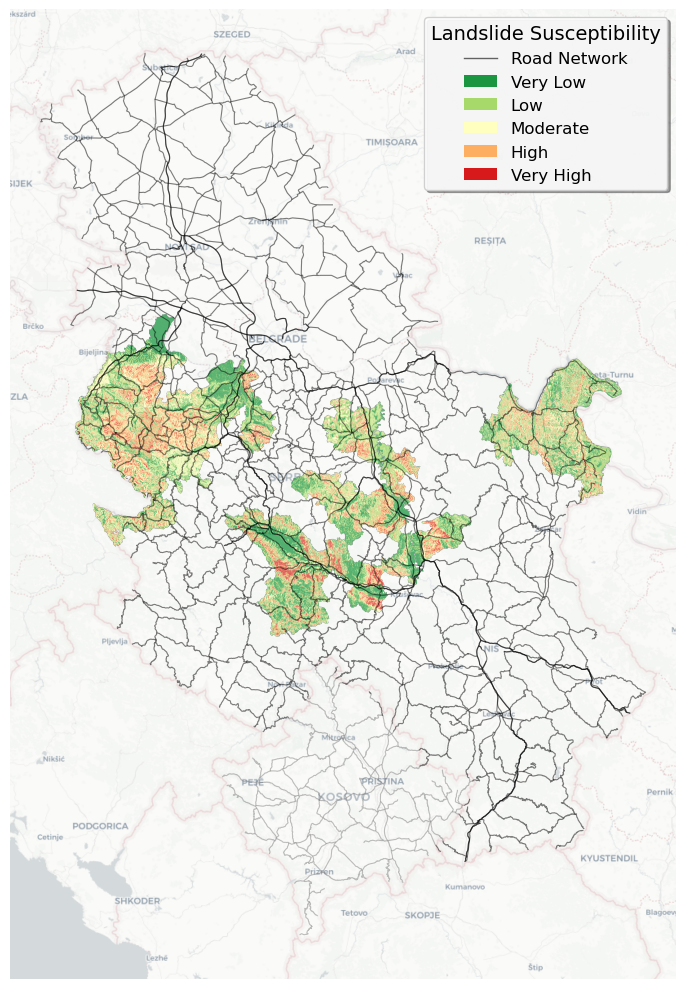

In [80]:
with rasterio.open(landslide_path) as src:
    landslide_data = src.read(1).astype(float)
    landslide_data[landslide_data == src.nodata] = np.nan
    landslide_bounds = src.bounds
    landslide_crs = src.crs

    # Reproject bounds to Web Mercator for display
    from rasterio.warp import transform_bounds
    bounds_mercator = transform_bounds(landslide_crs, "EPSG:3857",
                                       landslide_bounds.left, landslide_bounds.bottom,
                                       landslide_bounds.right, landslide_bounds.top)

# Define susceptibility bins and labels (discrete values: 2, 4, 6, 8, 10)
susc_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
susc_colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
susc_cmap = mcolors.ListedColormap(susc_colors)
susc_bounds = [1, 3, 5, 7, 9, 11]  # Boundaries around 2, 4, 6, 8, 10
susc_norm = mcolors.BoundaryNorm(susc_bounds, susc_cmap.N)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Convert country outline to Web Mercator
serbia_mercator = country_plot.to_crs(3857)
baseline_mercator = baseline_roads.to_crs(3857)

# Map discrete values to color indices explicitly
color_array = np.full((*landslide_data.shape, 4), np.nan)
value_to_color = {
    2:  mcolors.to_rgba('#1a9641', alpha=0.75),  # Very Low
    4:  mcolors.to_rgba('#a6d96a', alpha=0.75),  # Low
    6:  mcolors.to_rgba('#ffffbf', alpha=0.75),  # Moderate
    8:  mcolors.to_rgba('#fdae61', alpha=0.75),  # High
    10: mcolors.to_rgba('#d7191c', alpha=0.75),  # Very High
}
for val, rgba in value_to_color.items():
    mask = landslide_data == val
    color_array[mask] = rgba

# Set NaN pixels to transparent
nan_mask = np.isnan(landslide_data)
color_array[nan_mask] = (0, 0, 0, 0)

# Plot landslide susceptibility raster
img = ax.imshow(
    color_array,
    extent=[bounds_mercator[0], bounds_mercator[2],
            bounds_mercator[1], bounds_mercator[3]],
    zorder=2,
    origin='upper'
)

# Plot country outline
#serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',linewidth=1.5, zorder=4)

# Plot baseline road network in black and grey
serbia_roads_mercator.plot(ax=ax, color='black', linewidth=0.8, 
                       alpha=0.5, zorder=2)
kosovo_roads_mercator.plot(ax=ax, color='grey', linewidth=0.8, 
                       alpha=0.5, zorder=2)

# Add basemap
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)

ax.set_aspect('equal')
ax.axis('off')

# Create legend
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6)
] + [
    Patch(facecolor=susc_colors[i], edgecolor='none', label=susc_labels[i])
    for i in range(len(susc_labels))
]

ax.legend(handles=legend_elements, title='Landslide Susceptibility', loc='upper right',
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'landslide_susceptibility_map.png', dpi=600, bbox_inches='tight')
plt.show()
